In [1]:
!git clone https://github.com/MachineLearningVisionRG/IKDD.git
!ls IKDD/IKDD | head

Cloning into 'IKDD'...
remote: Enumerating objects: 579, done.
remote: Counting objects: 100% (579/579), done.
remote: Compressing objects: 100% (575/575), done.
remote: Total 579 (delta 543), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (579/579), 6.07 MiB | 1.80 MiB/s, done.
Resolving deltas: 100% (543/543), done.
Updating files: 100% (534/534), done.
any_ks&dl_user001_(1).txt
any_ks&dl_user002_(1).txt
any_ks&dl_user002_(2).txt
any_ks&dl_user002_(3).txt
any_ks&dl_user002_(4).txt
any_ks&dl_user002_(5).txt
any_ks&dl_user003_(1).txt
any_ks&dl_user003_(2).txt
any_ks&dl_user003_(3).txt
any_ks&dl_user003_(4).txt


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


In [3]:
base_path = "IKDD/IKDD"   # folder containing text files
files = [os.path.join(base_path, f) for f in os.listdir(base_path) if f.endswith(".txt")]
print(f"Found {len(files)} files")

Found 533 files


In [4]:
import re
import numpy as np
import pandas as pd

def parse_ikdd_file(path):
    """
    Parses one IKDD file robustly — handles Unicode dashes and commas.
    Returns metadata dict and DataFrame with (key1, key2, mean_value).
    """
    with open(path, "r", encoding="utf-8") as f:
        lines = [ln.strip() for ln in f if ln.strip()]

    # --- Metadata line ---
    meta_parts = lines[0].split(",")
    meta = {
        "user_id": meta_parts[0],
        "gender": meta_parts[1],
        "age_group": meta_parts[2],
        "handedness": meta_parts[3],
        "language": meta_parts[4],
        "education": meta_parts[5],
        "device": meta_parts[6] if len(meta_parts) > 6 else None,
        "session": meta_parts[7] if len(meta_parts) > 7 else None,
    }

    # --- Keystroke records ---
    records = []
    dash_pattern = re.compile(r"[\u2013\u2014-]")  # match any dash type

    for line in lines[1:]:
        try:
            keypair, *vals = line.split(",")
            # normalize dash and split
            keypair = dash_pattern.split(keypair)
            if len(keypair) != 2:
                continue
            key1, key2 = map(int, keypair)
            values = [float(v) for v in vals if v.strip()]
            if values:
                records.append({
                    "key1": key1,
                    "key2": key2,
                    "values": np.mean(values)
                })
        except Exception:
            continue

    df = pd.DataFrame(records)
    if not df.empty:
        df["user_id"] = meta["user_id"]
    return meta, df


# ---- Parse all files ----
meta_list, dfs = [], []
for path in files:
    meta, df = parse_ikdd_file(path)
    meta_list.append(meta)
    if not df.empty:
        dfs.append(df)

meta_df = pd.DataFrame(meta_list)
data_df = pd.concat(dfs, ignore_index=True)
print("Meta shape:", meta_df.shape)
print("Data shape:", data_df.shape)
data_df.head()


Meta shape: (533, 8)
Data shape: (276782, 4)


,key1,key2,values,user_id
0,32,0,94.604396,user105_(2)
1,33,0,107.875000,user105_(2)
2,34,0,63.915888,user105_(2)
3,37,0,77.083333,user105_(2)
4,39,0,64.351852,user105_(2)


In [5]:
# Separate durations and latencies
durations = (
    data_df[data_df["key2"] == 0]
    .groupby("user_id")["values"].mean()
    .rename("mean_duration")
)
latencies = (
    data_df[data_df["key2"] != 0]
    .groupby("user_id")["values"].mean()
    .rename("mean_latency")
)

feat_df = pd.concat([durations, latencies], axis=1).reset_index()
feat_df = feat_df.merge(meta_df[["user_id", "age_group"]], on="user_id", how="left")
feat_df = feat_df.dropna(subset=["mean_duration", "mean_latency", "age_group"])
feat_df.head()

,user_id,mean_duration,mean_latency,age_group
0,user001_(1),95.616277,290.819628,18-25
1,user002_(1),112.992126,318.490123,18-25
2,user002_(2),118.183187,349.642184,18-25
3,user002_(3),118.949206,390.043655,18-25
4,user002_(4),111.430929,323.293830,18-25


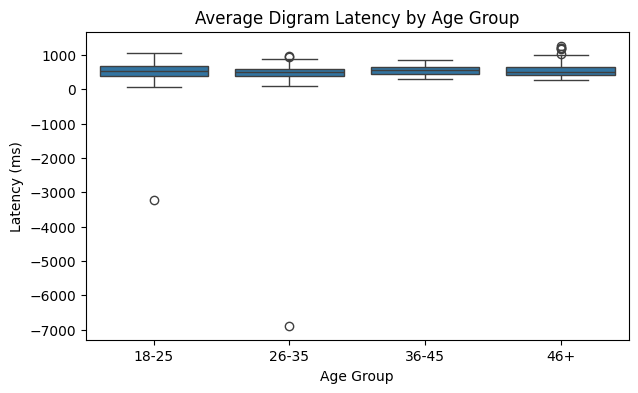

In [6]:
plt.figure(figsize=(7,4))
sns.boxplot(
    data=feat_df,
    x="age_group",
    y="mean_latency",
    order=sorted(feat_df["age_group"].unique())
)
plt.title("Average Digram Latency by Age Group")
plt.ylabel("Latency (ms)")
plt.xlabel("Age Group")
plt.show()

Original number of participants: 533
Number of participants after outlier removal: 522


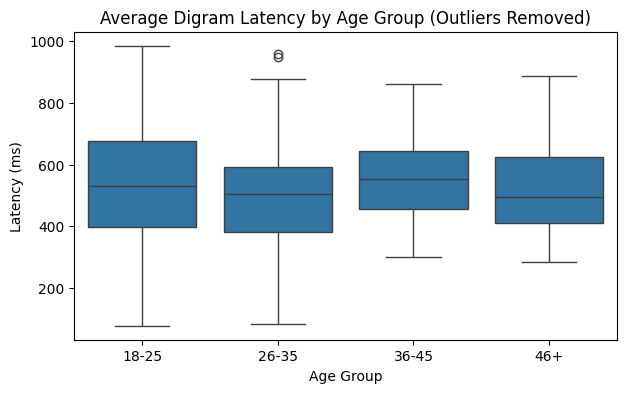

In [7]:
# Calculate IQR for mean_latency
Q1 = feat_df["mean_latency"].quantile(0.25)
Q3 = feat_df["mean_latency"].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
feat_df_filtered = feat_df[
    (feat_df["mean_latency"] >= lower_bound) & (feat_df["mean_latency"] <= upper_bound)
]

print(f"Original number of participants: {len(feat_df)}")
print(f"Number of participants after outlier removal: {len(feat_df_filtered)}")

plt.figure(figsize=(7, 4))
sns.boxplot(
    data=feat_df_filtered,
    x="age_group",
    y="mean_latency",
    order=sorted(feat_df_filtered["age_group"].unique()),
)
plt.title("Average Digram Latency by Age Group (Outliers Removed)")
plt.ylabel("Latency (ms)")
plt.xlabel("Age Group")
plt.show()

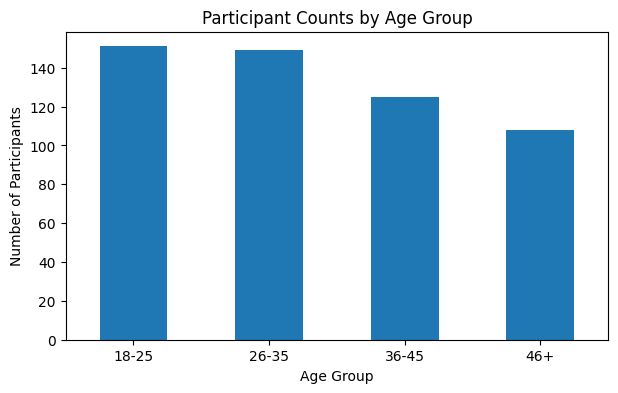

In [8]:
age_group_counts = feat_df["age_group"].value_counts().sort_index()
plt.figure(figsize=(7, 4))
age_group_counts.plot(kind="bar")
plt.title("Participant Counts by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Participants")
plt.xticks(rotation=0)
plt.show()

In [9]:
# =====================================================
# FINALIZED PREPROCESSING PIPELINE (CLEAN + SAFE)
# =====================================================

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split

# --- Helper: Drop sparse columns ---
def drop_sparse(df, min_users=20):
    """Keep only columns with at least min_users non-null entries."""
    non_null_counts = df.notna().sum()
    keep_cols = non_null_counts[non_null_counts >= min_users].index
    return df[keep_cols]

# --- 1. Split durations and digrams ---
dur_df = data_df[data_df["key2"] == 0].copy()
dur_feat = dur_df.pivot_table(index="user_id", columns="key1", values="values", aggfunc="mean")
dur_feat.columns = [f"dur_{int(c)}" for c in dur_feat.columns]
dur_feat = drop_sparse(dur_feat, min_users=20)

lat_df = data_df[data_df["key2"] != 0].copy()
lat_df["dig"] = lat_df["key1"].astype(int).astype(str) + "_" + lat_df["key2"].astype(int).astype(str)
dig_feat = lat_df.pivot_table(index="user_id", columns="dig", values="values", aggfunc="mean")
dig_feat.columns = [f"dig_{c}" for c in dig_feat.columns]
dig_feat = drop_sparse(dig_feat, min_users=20)

# --- 2. Merge ---
features = pd.concat([dur_feat, dig_feat], axis=1)
features.index.name = "user_id"
features = features.reset_index()

feat_all = features.merge(meta_df[["user_id", "age_group"]], on="user_id", how="left")
feat_all = feat_all.dropna(subset=["age_group"]).reset_index(drop=True)

print(f"Raw feature matrix: {feat_all.shape[0]} users × {feat_all.shape[1]-2} features")

# --- 3. Remove ultra-sparse columns (>60% NaN) ---
nan_ratio = feat_all.isna().mean()
keep_cols = nan_ratio[nan_ratio < 0.6].index

# ⚠️ Drop non-numeric columns explicitly
cols_to_use = [c for c in keep_cols if c not in ["user_id", "age_group"]]
feat_all = feat_all[cols_to_use + ["age_group"]]
print(f"After dropping sparse & non-numeric columns: {feat_all.shape[1]-1} numeric features remain")

# --- 4. Prepare numeric feature matrix ---
X = feat_all.drop(columns=["age_group"])
y = feat_all["age_group"]

# Impute missing with column median (safe now)
imp = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imp.fit_transform(X), columns=X.columns)

# Encode age groups
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Select top-K features by ANOVA F-test
K = 300
selector = SelectKBest(score_func=f_classif, k=min(K, X_imp.shape[1]))
X_sel = selector.fit_transform(X_imp, y_enc)
selected_columns = X_imp.columns[selector.get_support()]
print(f"Selected {len(selected_columns)} informative features")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sel)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.3, random_state=42, stratify=y_enc
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Feature count after selection: {X_train.shape[1]}")

Raw feature matrix: 533 users × 1989 features
After dropping sparse & non-numeric columns: 426 numeric features remain
Selected 300 informative features
Train size: 373, Test size: 160
Feature count after selection: 300


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters: {'C': 10, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-Val Accuracy: 0.6325405405405405

Tuned SVM Test Report:
              precision    recall  f1-score   support

       18-25       0.67      0.78      0.72        45
       26-35       0.59      0.53      0.56        45
       36-45       0.61      0.61      0.61        38
         46+       0.66      0.59      0.62        32

    accuracy                           0.63       160
   macro avg       0.63      0.63      0.63       160
weighted avg       0.63      0.63      0.63       160



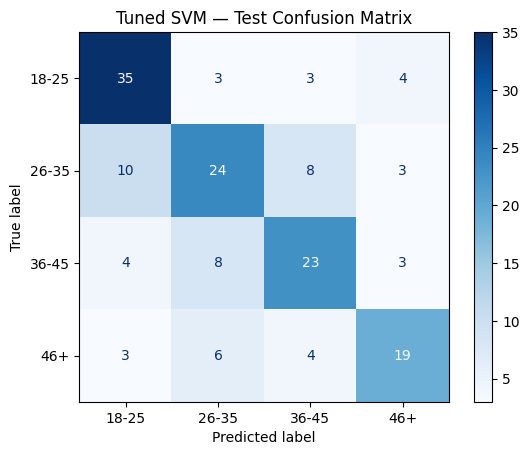

In [10]:
# =====================================================
# HYPERPARAMETER TUNING FOR SVM (RBF + Linear)
# =====================================================

from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.1, 0.01, 0.001],
    "kernel": ["rbf", "poly"],
    "class_weight": ["balanced"]
}

svm = SVC(random_state=42)

grid = GridSearchCV(
    svm, param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=2
)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross-Val Accuracy:", grid.best_score_)

best_svm = grid.best_estimator_
y_pred_tuned = best_svm.predict(X_test)

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("\nTuned SVM Test Report:")
print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned, display_labels=le.classes_, cmap="Blues"
)
plt.title("Tuned SVM — Test Confusion Matrix")
plt.show()


Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters: {'C': 5, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
Cross-Val Accuracy: 0.6166126126126127

Optimized SVM Test Report:
              precision    recall  f1-score   support

       18-25       0.73      0.80      0.77        45
       26-35       0.58      0.47      0.52        45
       36-45       0.51      0.61      0.55        38
         46+       0.67      0.62      0.65        32

    accuracy                           0.62       160
   macro avg       0.62      0.62      0.62       160
weighted avg       0.63      0.62      0.62       160



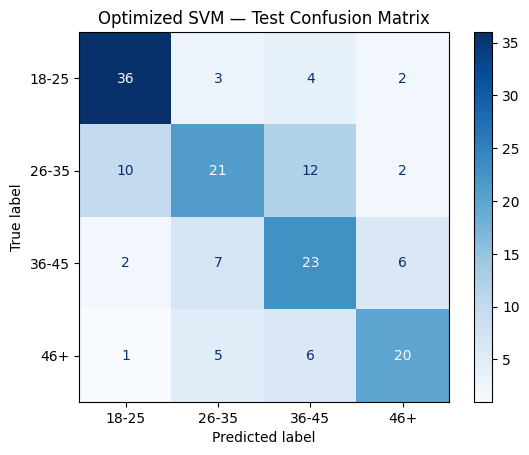

In [11]:
# =====================================================
# FINAL OPTIMIZED SVM-ONLY PIPELINE (IKDD AGE PREDICTION)
# =====================================================

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import matplotlib.pyplot as plt

# --- Rebuild feature set with K=300 using mutual_info_classif ---
K = 300
selector = SelectKBest(score_func=mutual_info_classif, k=min(K, X_imp.shape[1]))
X_sel = selector.fit_transform(X_imp, y_enc)
selected_columns = X_imp.columns[selector.get_support()]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sel)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.3, random_state=42, stratify=y_enc
)

# --- Fine-grained parameter search ---
param_grid = {
    "C": [5, 10, 20],
    "gamma": [0.01, 0.05, 0.1, "scale"],
    "kernel": ["rbf"],
    "class_weight": ["balanced"]
}

svm = SVC(probability=True, random_state=42)

grid = GridSearchCV(
    svm, param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=1
)
grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)
print("Cross-Val Accuracy:", grid.best_score_)

best_svm = grid.best_estimator_

# --- Evaluate on test set ---
y_pred = best_svm.predict(X_test)
print("\nOptimized SVM Test Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=le.classes_, cmap="Blues"
)
plt.title("Optimized SVM — Test Confusion Matrix")
plt.show()

In [12]:
# # =====================================================
# # FULL SVM SWEEP: digram-only vs combined features
# # =====================================================

# import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import LabelEncoder, StandardScaler
# from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
# from sklearn.model_selection import train_test_split, GridSearchCV
# from sklearn.svm import SVC
# from sklearn.metrics import classification_report
# from tqdm import tqdm

# # ---------- Helper functions ----------
# def drop_sparse(df, min_users=20):
#     non_null_counts = df.notna().sum()
#     keep_cols = non_null_counts[non_null_counts >= min_users].index
#     return df[keep_cols]

# def oldbuild_features(data_df, meta_df, use_digrams_only=True, min_users=20, nan_thresh=0.6):
#     """Build either digram-only or combined feature set (per paper logic)."""
#     if use_digrams_only:
#         lat_df = data_df[data_df["key2"] != 0].copy()
#         lat_df["dig"] = lat_df["key1"].astype(int).astype(str) + "_" + lat_df["key2"].astype(int).astype(str)
#         # enforce ≥3 occurrences per user per digram
#         counts = lat_df.groupby(["user_id", "dig"]).size().reset_index(name="count")
#         valid = counts[counts["count"] >= 3][["user_id", "dig"]]
#         lat_df = lat_df.merge(valid, on=["user_id", "dig"], how="inner")
#         dig_feat = lat_df.pivot_table(index="user_id", columns="dig", values="values", aggfunc="mean")
#         dig_feat.columns = [f"dig_{c}" for c in dig_feat.columns]
#         dig_feat = drop_sparse(dig_feat, min_users)
#         features = dig_feat.reset_index()
#     else:
#         # durations
#         dur_df = data_df[data_df["key2"] == 0].copy()
#         dur_feat = dur_df.pivot_table(index="user_id", columns="key1", values="values", aggfunc="mean")
#         dur_feat.columns = [f"dur_{int(c)}" for c in dur_feat.columns]
#         dur_feat = drop_sparse(dur_feat, min_users)
#         # digrams
#         lat_df = data_df[data_df["key2"] != 0].copy()
#         lat_df["dig"] = lat_df["key1"].astype(int).astype(str) + "_" + lat_df["key2"].astype(int).astype(str)
#         dig_feat = lat_df.pivot_table(index="user_id", columns="dig", values="values", aggfunc="mean")
#         dig_feat.columns = [f"dig_{c}" for c in dig_feat.columns]
#         dig_feat = drop_sparse(dig_feat, min_users)
#         features = pd.concat([dur_feat, dig_feat], axis=1).reset_index()

#     feat_all = features.merge(meta_df[["user_id", "age_group"]], on="user_id", how="left")
#     feat_all = feat_all.dropna(subset=["age_group"]).reset_index(drop=True)
#     nan_ratio = feat_all.isna().mean()
#     keep_cols = nan_ratio[nan_ratio < nan_thresh].index
#     cols_to_use = [c for c in keep_cols if c not in ("user_id", "age_group")]
#     feat_all = feat_all[cols_to_use + ["age_group"]]

#     X = feat_all.drop(columns=["age_group"])
#     y = feat_all["age_group"]
#     imp = SimpleImputer(strategy="median")
#     X_imp = pd.DataFrame(imp.fit_transform(X), columns=X.columns)
#     le = LabelEncoder()
#     y_enc = le.fit_transform(y)
#     return X_imp, y_enc, le

# def build_features(data_df, meta_df, use_digrams_only=True, min_users=2, nan_thresh=0.8):
#     """Build either digram-only or combined feature set (paper logic)."""
#     if use_digrams_only:
#         lat_df = data_df[data_df["key2"] != 0].copy()
#         lat_df["dig"] = lat_df["key1"].astype(int).astype(str) + "_" + lat_df["key2"].astype(int).astype(str)

#         # enforce ≥3 occurrences per user per digram
#         counts = lat_df.groupby(["user_id", "dig"]).size().reset_index(name="count")
#         valid = counts[counts["count"] >= 3][["user_id", "dig"]]
#         lat_df = lat_df.merge(valid, on=["user_id", "dig"], how="inner")

#         dig_feat = lat_df.pivot_table(index="user_id", columns="dig", values="values", aggfunc="mean")
#         dig_feat.columns = [f"dig_{c}" for c in dig_feat.columns]

#         # relax sparse filtering
#         dig_feat = drop_sparse(dig_feat, min_users)
#         print(f"ℹ️ Digram-only: {dig_feat.shape[1]} features before NaN filtering")

#         features = dig_feat.reset_index()
#     else:
#         # durations
#         dur_df = data_df[data_df["key2"] == 0].copy()
#         dur_feat = dur_df.pivot_table(index="user_id", columns="key1", values="values", aggfunc="mean")
#         dur_feat.columns = [f"dur_{int(c)}" for c in dur_feat.columns]
#         dur_feat = drop_sparse(dur_feat, min_users)

#         # digrams
#         lat_df = data_df[data_df["key2"] != 0].copy()
#         lat_df["dig"] = lat_df["key1"].astype(int).astype(str) + "_" + lat_df["key2"].astype(int).astype(str)
#         dig_feat = lat_df.pivot_table(index="user_id", columns="dig", values="values", aggfunc="mean")
#         dig_feat.columns = [f"dig_{c}" for c in dig_feat.columns]
#         dig_feat = drop_sparse(dig_feat, min_users)

#         print(f"ℹ️ Combined: durations={dur_feat.shape[1]}, digrams={dig_feat.shape[1]}")
#         features = pd.concat([dur_feat, dig_feat], axis=1).reset_index()

#     # merge metadata
#     feat_all = features.merge(meta_df[["user_id", "age_group"]], on="user_id", how="left")
#     feat_all = feat_all.dropna(subset=["age_group"]).reset_index(drop=True)

#     # drop columns with too many NaNs
#     nan_ratio = feat_all.isna().mean()
#     keep_cols = nan_ratio[nan_ratio < nan_thresh].index
#     cols_to_use = [c for c in keep_cols if c not in ("user_id", "age_group")]
#     feat_all = feat_all[cols_to_use + ["age_group"]]

#     if len(cols_to_use) == 0:
#         print("⚠️ No usable features found after filtering — returning None.")
#         return None, None, None

#     # impute & encode
#     X = feat_all.drop(columns=["age_group"])
#     y = feat_all["age_group"]
#     imp = SimpleImputer(strategy="median")
#     X_imp = pd.DataFrame(imp.fit_transform(X), columns=X.columns)
#     le = LabelEncoder()
#     y_enc = le.fit_transform(y)

#     return X_imp, y_enc, le

# # ---------- SVM tuning helper ----------
# def train_svm(X, y, K, selector_type="f_test"):
#     if selector_type == "mutual":
#         selector = SelectKBest(score_func=mutual_info_classif, k=min(K, X.shape[1]))
#     else:
#         selector = SelectKBest(score_func=f_classif, k=min(K, X.shape[1]))
#     X_sel = selector.fit_transform(X, y)
#     scaler = StandardScaler()
#     X_scaled = scaler.fit_transform(X_sel)
#     X_train, X_test, y_train, y_test = train_test_split(
#         X_scaled, y, test_size=0.3, random_state=42, stratify=y
#     )

#     param_grid = {
#         "C": [5, 10, 20],
#         "gamma": [0.005, 0.01, 0.05, "scale"],
#         "kernel": ["rbf"],
#         "class_weight": ["balanced"]
#     }

#     svm = SVC(probability=True, random_state=42)
#     grid = GridSearchCV(svm, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
#     grid.fit(X_train, y_train)
#     best_svm = grid.best_estimator_

#     acc = grid.score(X_test, y_test)
#     return acc, grid.best_params_

# # ---------- Sweep experiment ----------
# configs = []

# for use_digrams_only in [True, False]:
#     for selector_type in ["f_test", "mutual"]:
#         for K in [100, 200, 300, 400, 500, 700]:
#             print(f"\nRunning config: digrams_only={use_digrams_only}, selector={selector_type}, K={K}")

#             X_imp, y_enc, le = build_features(data_df, meta_df, use_digrams_only)

#             # Skip configs with no usable features
#             if X_imp is None or y_enc is None:
#                 print("⚠️ Skipping this configuration (no usable features).")
#                 continue

#             try:
#                 acc, params = train_svm(X_imp, y_enc, K, selector_type)
#                 configs.append({
#                     "use_digrams_only": use_digrams_only,
#                     "selector": selector_type,
#                     "K": K,
#                     "accuracy": acc,
#                     "params": params
#                 })
#             except Exception as e:
#                 print(f"❌ Error in config (K={K}): {e}")
#                 continue

# print("\n✅ Sweep completed.")
# df_results = pd.DataFrame(configs)
# display(df_results.sort_values("accuracy", ascending=False).head(10))

# plt.figure(figsize=(8,4))
# sns.lineplot(data=df_results, x="K", y="accuracy", hue="selector", style="use_digrams_only", markers=True)
# plt.title("SVM Accuracy vs Feature Count K (Digrams-Only vs Combined)")
# plt.ylabel("Test Accuracy")
# plt.xlabel("Feature Count (K)")
# plt.ylim(0.5, 0.75)
# plt.show()

Done: selector=f_test, K=100, acc=0.625
Done: selector=f_test, K=200, acc=0.694
Done: selector=f_test, K=300, acc=0.662
Done: selector=f_test, K=400, acc=0.650
Done: selector=f_test, K=500, acc=0.594
Done: selector=f_test, K=700, acc=0.631
Done: selector=mutual, K=100, acc=0.600
Done: selector=mutual, K=200, acc=0.650
Done: selector=mutual, K=300, acc=0.619
Done: selector=mutual, K=400, acc=0.637
Done: selector=mutual, K=500, acc=0.656
Done: selector=mutual, K=700, acc=0.619


,selector,K,acc,params
0,f_test,200,0.69375,"{'C': 10, 'class_weight': 'balanced', 'gamma':..."
1,f_test,300,0.66250,"{'C': 5, 'class_weight': 'balanced', 'gamma': ..."
2,mutual,500,0.65625,"{'C': 5, 'class_weight': 'balanced', 'gamma': ..."
3,f_test,400,0.65000,"{'C': 5, 'class_weight': 'balanced', 'gamma': ..."
4,mutual,200,0.65000,"{'C': 5, 'class_weight': 'balanced', 'gamma': ..."
5,mutual,400,0.63750,"{'C': 5, 'class_weight': 'balanced', 'gamma': ..."
6,f_test,700,0.63125,"{'C': 10, 'class_weight': 'balanced', 'gamma':..."
7,f_test,100,0.62500,"{'C': 10, 'class_weight': 'balanced', 'gamma':..."
8,mutual,300,0.61875,"{'C': 10, 'class_weight': 'balanced', 'gamma':..."
9,mutual,700,0.61875,"{'C': 5, 'class_weight': 'balanced', 'gamma': ..."


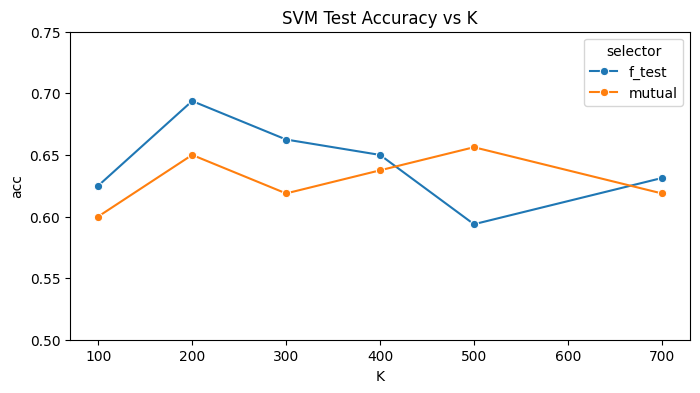


Best configuration:
selector                                               f_test
K                                                         200
acc                                                   0.69375
params      {'C': 10, 'class_weight': 'balanced', 'gamma':...
Name: 0, dtype: object

=== Final Evaluation ===
              precision    recall  f1-score   support

       18-25       0.76      0.78      0.77        45
       26-35       0.70      0.73      0.72        45
       36-45       0.66      0.61      0.63        38
         46+       0.62      0.62      0.62        32

    accuracy                           0.69       160
   macro avg       0.69      0.69      0.69       160
weighted avg       0.69      0.69      0.69       160

Overall Accuracy: 0.694


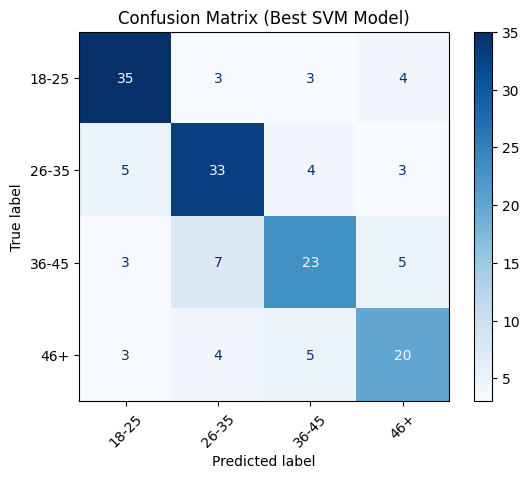

In [13]:
# =====================================================
# FINAL CLEAN VERSION — IKDD Age Group Classification (SVM)
# =====================================================

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ---------------- Helper ----------------
def drop_sparse(df, min_users=2):
    return df.loc[:, df.notna().sum() >= min_users]

# ---------------- Feature Builder ----------------
def build_features(data_df, meta_df, min_users=2, nan_thresh=0.8):
    # durations
    dur_df = data_df[data_df["key2"] == 0].copy()
    dur_feat = dur_df.pivot_table(index="user_id", columns="key1", values="values", aggfunc="mean")
    dur_feat.columns = [f"dur_{int(c)}" for c in dur_feat.columns]
    dur_feat = drop_sparse(dur_feat, min_users)

    # digrams
    lat_df = data_df[data_df["key2"] != 0].copy()
    lat_df["dig"] = lat_df["key1"].astype(int).astype(str) + "_" + lat_df["key2"].astype(int).astype(str)
    dig_feat = lat_df.pivot_table(index="user_id", columns="dig", values="values", aggfunc="mean")
    dig_feat.columns = [f"dig_{c}" for c in dig_feat.columns]
    dig_feat = drop_sparse(dig_feat, min_users)

    features = pd.concat([dur_feat, dig_feat], axis=1).reset_index()
    feat_all = features.merge(meta_df[["user_id", "age_group"]], on="user_id", how="left")
    feat_all = feat_all.dropna(subset=["age_group"]).reset_index(drop=True)

    # drop columns with excessive NaNs
    nan_ratio = feat_all.isna().mean()
    keep_cols = nan_ratio[nan_ratio < nan_thresh].index
    cols_to_use = [c for c in keep_cols if c not in ("user_id", "age_group")]
    feat_all = feat_all[cols_to_use + ["age_group"]]

    # impute + encode
    X = feat_all.drop(columns=["age_group"])
    y = feat_all["age_group"]
    imp = SimpleImputer(strategy="median")
    X_imp = pd.DataFrame(imp.fit_transform(X), columns=X.columns)
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    return X_imp, y_enc, le

# ---------------- Train + Evaluate SVM ----------------
def train_svm(X, y, K=300, selector="f_test"):
    selector_func = f_classif if selector == "f_test" else mutual_info_classif
    selector = SelectKBest(score_func=selector_func, k=min(K, X.shape[1]))
    X_sel = selector.fit_transform(X, y)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_sel)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42, stratify=y
    )

    param_grid = {
        "C": [5, 10, 20],
        "gamma": [0.005, 0.01, 0.05, "scale"],
        "kernel": ["rbf"],
        "class_weight": ["balanced"],
    }

    svm = SVC(probability=True, random_state=42)
    grid = GridSearchCV(svm, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)

    best_svm = grid.best_estimator_
    y_pred = best_svm.predict(X_test)
    acc = np.mean(y_pred == y_test)

    return best_svm, selector, scaler, acc, y_test, y_pred, grid.best_params_

# ---------------- MAIN PIPELINE ----------------
X_imp, y_enc, le = build_features(data_df, meta_df)
results = []

for selector_type in ["f_test", "mutual"]:
    for K in [100, 200, 300, 400, 500, 700]:
        best_svm, selector, scaler, acc, y_test, y_pred, params = train_svm(X_imp, y_enc, K, selector_type)
        results.append({"selector": selector_type, "K": K, "acc": acc, "params": params})
        print(f"Done: selector={selector_type}, K={K}, acc={acc:.3f}")

df_results = pd.DataFrame(results).sort_values("acc", ascending=False).reset_index(drop=True)
display(df_results.head(10))

plt.figure(figsize=(8,4))
sns.lineplot(data=df_results, x="K", y="acc", hue="selector", marker="o")
plt.title("SVM Test Accuracy vs K")
plt.ylim(0.5, 0.75)
plt.show()

# ---------------- Evaluate Best Model ----------------
best = df_results.iloc[0]
print("\nBest configuration:")
print(best)

best_svm, selector, scaler, acc, y_test, y_pred, params = train_svm(
    X_imp, y_enc, int(best.K), best.selector
)

print("\n=== Final Evaluation ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print(f"Overall Accuracy: {acc:.3f}")

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix (Best SVM Model)")
plt.show()


🔍 Fine-tuning around K=200...
K=198  →  acc=0.669,  params={'C': 10, 'class_weight': 'balanced', 'gamma': 0.005, 'kernel': 'rbf'}
K=199  →  acc=0.681,  params={'C': 10, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
K=200  →  acc=0.694,  params={'C': 10, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
K=201  →  acc=0.700,  params={'C': 10, 'class_weight': 'balanced', 'gamma': 0.005, 'kernel': 'rbf'}
K=202  →  acc=0.681,  params={'C': 10, 'class_weight': 'balanced', 'gamma': 0.005, 'kernel': 'rbf'}


,K,acc,params
0,198,0.66875,"{'C': 10, 'class_weight': 'balanced', 'gamma':..."
1,199,0.68125,"{'C': 10, 'class_weight': 'balanced', 'gamma':..."
2,200,0.69375,"{'C': 10, 'class_weight': 'balanced', 'gamma':..."
3,201,0.70000,"{'C': 10, 'class_weight': 'balanced', 'gamma':..."
4,202,0.68125,"{'C': 10, 'class_weight': 'balanced', 'gamma':..."


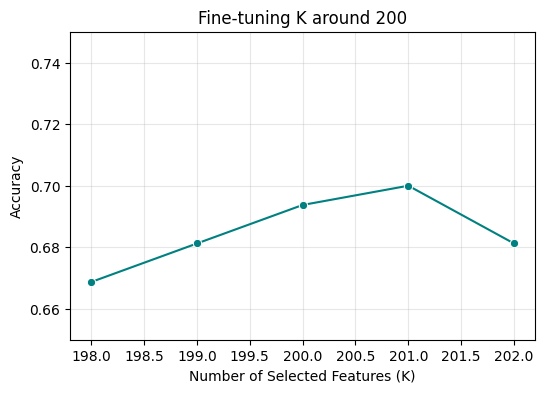


🏆 Best fine-tuned K = 201, Accuracy = 0.700
Best Params: {'C': 10, 'class_weight': 'balanced', 'gamma': 0.005, 'kernel': 'rbf'}


In [14]:
# ------------------------------------------
# Fine-tune K in small steps around 200
# ------------------------------------------
from sklearn.model_selection import GridSearchCV

K_values = [198, 199, 200, 201, 202]
fine_results = []

print("\n🔍 Fine-tuning around K=200...")

for K in K_values:
    best_svm, selector, scaler, acc, y_test, y_pred, params = train_svm(X_imp, y_enc, K=K, selector="f_test")
    fine_results.append({"K": K, "acc": acc, "params": params})
    print(f"K={K:<3}  →  acc={acc:.3f},  params={params}")

df_fine = pd.DataFrame(fine_results)
display(df_fine)

plt.figure(figsize=(6,4))
sns.lineplot(data=df_fine, x="K", y="acc", marker="o", color="teal")
plt.title("Fine-tuning K around 200")
plt.ylabel("Accuracy")
plt.xlabel("Number of Selected Features (K)")
plt.ylim(0.65, 0.75)
plt.grid(True, alpha=0.3)
plt.show()

best_fine = df_fine.iloc[df_fine["acc"].idxmax()]
print(f"\n🏆 Best fine-tuned K = {best_fine.K}, Accuracy = {best_fine.acc:.3f}")
print(f"Best Params: {best_fine.params}")

In [15]:
!pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 75.0 MB/s eta 0:00:00


#### Save the best model and preprocessing objects

In [16]:
import joblib

# Define filenames for saving
model_filename = 'best_svm_model.joblib'
scaler_filename = 'scaler.joblib'
selector_filename = 'selector.joblib'

# Save the trained model
joblib.dump(best_svm, model_filename)
print(f"Best SVM model saved to {model_filename}")

# Save the scaler
joblib.dump(scaler, scaler_filename)
print(f"Scaler saved to {scaler_filename}")

# Save the feature selector
joblib.dump(selector, selector_filename)
print(f"Feature selector saved to {selector_filename}")

Best SVM model saved to best_svm_model.joblib
Scaler saved to scaler.joblib
Feature selector saved to selector.joblib


In [17]:
!pip install skl2onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 63.7 MB/s eta 0:00:00


In [18]:
import joblib
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

# Load the saved model and preprocessing objects
best_svm = joblib.load('best_svm_model.joblib')
scaler = joblib.load('scaler.joblib')
selector = joblib.load('selector.joblib')

# Define initial types for ONNX conversion
# The input to the SVM model (X_scaled) was an array of floats after scaling and selection.
# We need to determine the number of features after selection (K).
# Let's use the K value from the best_fine configuration which was 201.
initial_type = [('float_input', FloatTensorType([None, 201]))]

# Convert the SVM model to ONNX format
# Note: skl2onnx converts the estimator directly. Preprocessing steps need to be handled separately
# if they are to be included in the ONNX graph. For simplicity, we are converting just the SVM.
# To include scaler/selector in the ONNX graph, a sklearn.pipeline.Pipeline would be needed.
onx_model = convert_sklearn(best_svm, initial_types=initial_type)

# Save the ONNX model to a file
with open("best_svm_model.onnx", "wb") as f:
    f.write(onx_model.SerializeToString())

print("SVM model successfully converted to ONNX and saved as best_svm_model.onnx")

SVM model successfully converted to ONNX and saved as best_svm_model.onnx


In [20]:
!pip install onnxruntime skl2onnx

from sklearn.pipeline import Pipeline
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

# 1. Create a single pipeline containing all steps
full_pipeline = Pipeline([
    ('selector', selector),
    ('scaler', scaler),
    ('svm', best_svm)
])

# 2. Convert the entire pipeline to ONNX
# X_imp has 426 features before selection (from previous execution state)
initial_type = [('float_input', FloatTensorType([None, X_imp.shape[1]]))]
onx_pipeline = convert_sklearn(full_pipeline, initial_types=initial_type)

with open("full_pipeline_model.onnx", "wb") as f:
    f.write(onx_pipeline.SerializeToString())

print("Integrated Pipeline saved as full_pipeline_model.onnx")

Integrated Pipeline saved as full_pipeline_model.onnx


In [23]:
import onnxruntime as rt
import pandas as pd
import numpy as np
import re
import json

# ==================================================================
# 1. BAKE METADATA (Run this section once to generate constants)
# ==================================================================
# If variables exist in memory, we convert them to static constants.
# If you are running this for the first time after a restart, ensure
# you have run the training/preprocessing cells once.
try:
    FEATURE_COLS = X_imp.columns.tolist()
    FEATURE_MEDIANS = X_imp.median().to_dict()
    LABELS = le.classes_.tolist()

    # Note to user: If you want to move this code to a production script,
    # you can print() these variables and paste them here as fixed lists/dicts.
except NameError:
    print("CRITICAL: Training variables (X_imp, le) not found.")
    print("Please run the feature building cell (1L5GZTQdfcLo) and the selection cell (YDONKdO8gOZw) first.")
    raise

# ==================================================================
# 2. ESSENTIAL HELPER FUNCTION
# ==================================================================
def parse_ikdd_file(path):
    with open(path, "r", encoding="utf-8") as f:
        lines = [ln.strip() for ln in f if ln.strip()]
    meta_p = lines[0].split(",")
    meta = {"user_id": meta_p[0], "age_group": meta_p[2]}
    records = []
    dash_pattern = re.compile(r"[\u2013\u2014-]")
    for line in lines[1:]:
        try:
            kp, *vals = line.split(",")
            k1, k2 = map(int, dash_pattern.split(kp))
            if vals: records.append({"key1": k1, "key2": k2, "values": np.mean([float(v) for v in vals if v.strip()])})
        except: continue
    df = pd.DataFrame(records)
    if not df.empty: df["user_id"] = meta["user_id"]
    return meta, df

# ==================================================================
# 3. STANDALONE INFERENCE LOGIC
# ==================================================================
def predict_standalone(file_path, onnx_path):
    # Load session
    sess = rt.InferenceSession(onnx_path)

    # Parse input
    meta, df = parse_ikdd_file(file_path)
    if df.empty: return "No data", "N/A"

    # Feature Extraction
    dur = df[df['key2'] == 0].pivot_table(index='user_id', columns='key1', values='values', aggfunc='mean')
    dur.columns = [f'dur_{int(c)}' for c in dur.columns]
    lat = df[df['key2'] != 0].copy()
    lat['dig'] = lat['key1'].astype(str) + '_' + lat['key2'].astype(str)
    dig = lat.pivot_table(index='user_id', columns='dig', values='values', aggfunc='mean')
    dig.columns = [f'dig_{c}' for c in dig.columns]
    feats = pd.concat([dur, dig], axis=1)

    # Align to the features baked into the ONNX model
    X_input = pd.DataFrame(index=feats.index, columns=FEATURE_COLS)
    for col in FEATURE_COLS:
        if col in feats.columns:
            X_input[col] = feats[col]
        else:
            X_input[col] = FEATURE_MEDIANS[col]

    # Convert to numeric and ensure float32 for ONNX
    X_val = X_input.apply(pd.to_numeric).values.astype(np.float32)

    # ONNX Run
    input_name = sess.get_inputs()[0].name
    label_name = sess.get_outputs()[0].name
    pred_index = sess.run([label_name], {input_name: X_val})[0][0]

    return LABELS[pred_index], meta['age_group']

# ==================================================================
# 4. EXECUTION
# ==================================================================
test_file = 'IKDD/IKDD/any_ks&dl_user001_(1).txt'
onnx_file = 'full_pipeline_model.onnx' # Use the integrated model exported earlier

prediction, actual = predict_standalone(test_file, onnx_file)
print(f"File: {test_file}")
print(f"Predicted Age Group: {prediction}")
print(f"Actual Age Group: {actual}")

File: IKDD/IKDD/any_ks&dl_user001_(1).txt
Predicted Age Group: 18-25
Actual Age Group: 18-25
